# DroneRF Dataset Exploration & Verification

## Objective
To explore the DroneRF dataset and verify its contents, integrity, and suitability for RF-based anti-drone detection research.

## Research Question
What exactly does the DroneRF dataset contain, and is it suitable to serve as the foundation for our research?

## Expected Outcomes
- Verification of the project and dataset directory structure.
- Generation of a definitive metadata index mapping every raw CSV file.
- Analysis of dataset statistics, including class and receiver distributions.
- Assessment of RF signal characteristics through random sampling and visualization.


## Introduction

Radio Frequency (RF) based drone detection offers a passive, robust, and long-range alternative to acoustic or visual detection systems, particularly in adverse weather conditions or low-visibility environments. The DroneRF dataset provides a comprehensive collection of RF activities encompassing various drone models alongside background RF noise.

Before developing complex signal processing pipelines or deep learning models, it is crucial to rigorously verify the dataset. This verification ensures data integrity, identifies missing or corrupted files, and establishes a single source of truth (metadata) that will streamline all subsequent preprocessing, feature extraction, and model training phases.


## Import Libraries

**Why we are performing this step:** To import only the required libraries for directory traversal, metadata extraction, and plotting.
**What we expect to observe:** A clean namespace without redundant modules.
**Why it is important:** Keeping dependencies minimal maintains code clarity and prevents conflicts.


In [96]:
import sys
import json
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure visual style for publication-quality figures
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("paper", font_scale=1.2)
warnings.filterwarnings("ignore")


# Configuration
SAMPLE_SIZE = 10000  # Number of samples to load per representative recording

## Verify Project Structure

**Why we are performing this step:** To ensure the local environment mirrors the necessary repository structure for reproducibility.
**What we expect to observe:** Successful validation of `PROJECT_ROOT`, `DATA_DIR`, `RAW_DATA_DIR`, and `RAW_DATA_DIR / "DroneRF"`.
**Why it is important:** If standard paths are missing, all subsequent data parsing operations will fail.


In [97]:
# Import path utilities from the Vardhan project structure
# Assumes notebooks are run from the project root or the notebooks/ directory
sys.path.append(str(Path.cwd().parent))
try:
    from src.utils.paths import PROJECT_ROOT, DATA_DIR, RAW_DATA_DIR, FIGURES_DIR
except ImportError:
    # Fallback if src is not found in parent (e.g. running from root)
    sys.path.append(str(Path.cwd()))
    from src.utils.paths import PROJECT_ROOT, DATA_DIR, RAW_DATA_DIR, FIGURES_DIR

DRONERF_DIR = RAW_DATA_DIR / "DroneRF"

# Verification logic
required_dirs = {
    "Project Root": PROJECT_ROOT,
    "Data Directory": DATA_DIR,
    "Raw Data Directory": RAW_DATA_DIR,
    "DroneRF Directory": DRONERF_DIR
}

print("=== Project Structure Verification ===")
for name, dir_path in required_dirs.items():
    if dir_path.exists() and dir_path.is_dir():
        print(f"[✓] {name} found: {dir_path}")
    else:
        raise FileNotFoundError(f"Missing required directory: {name} at {dir_path}. Please check README.md for download instructions.")

# Ensure figure output directory for this notebook exists
NB_FIGURES_DIR = FIGURES_DIR / "notebook01"
NB_FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print(f"[✓] Figures Directory ready: {NB_FIGURES_DIR}")


=== Project Structure Verification ===
[✓] Project Root found: /Users/adithnarayan.g/Documents/Projects/Vardan
[✓] Data Directory found: /Users/adithnarayan.g/Documents/Projects/Vardan/data
[✓] Raw Data Directory found: /Users/adithnarayan.g/Documents/Projects/Vardan/data/raw
[✓] DroneRF Directory found: /Users/adithnarayan.g/Documents/Projects/Vardan/data/raw/DroneRF
[✓] Figures Directory ready: /Users/adithnarayan.g/Documents/Projects/Vardan/figures/notebook01


## Explore Dataset Structure

**Why we are performing this step:** To programmatically map the DroneRF directory and understand its high-level organization.
**What we expect to observe:** A hierarchy containing different drone classes and their corresponding extracted experiments.
**Why it is important:** Understanding the folder structure is a prerequisite for writing robust metadata extraction logic.


In [98]:
print("=== DroneRF Dataset Structure ===")
structure_data = []

# Traverse immediate subdirectories within DroneRF/
for class_dir in sorted(DRONERF_DIR.iterdir()):
    if class_dir.is_dir():
        csv_files = list(class_dir.rglob("*.csv"))
        zip_files = list(class_dir.rglob("*.zip"))
        # Count experiment folders by assuming folders containing CSVs are experiments
        exp_folders = {f.parent for f in csv_files}
        
        structure_data.append({
            "Folder Name": class_dir.name,
            "Number of Extracted Experiment Folders": len(exp_folders),
            "Number of ZIP Files": len(zip_files),
            "Number of CSV Files": len(csv_files)
        })

if not structure_data:
    print("Warning: No class directories found in DroneRF folder. Ensure the dataset is extracted.")

df_structure = pd.DataFrame(structure_data)
display(df_structure)


=== DroneRF Dataset Structure ===


,Folder Name,Number of Extracted Experiment Folders,Number of ZIP Files,Number of CSV Files
0,unzipped_data,23,0,454


## Dataset Integrity Verification

**Why we are performing this step:** To aggressively check for data anomalies such as missing files, empty folders, or empty CSVs.
**What we expect to observe:** No empty files/folders, no duplicate filenames, and correct presence of both High and Low receiver data.
**Why it is important:** Catching corrupted or incomplete data immediately prevents crashes during future preprocessing and modeling phases.


In [99]:
print("=== Dataset Integrity Verification ===")

empty_folders = []
empty_csvs = []
duplicate_filenames = set()
seen_filenames = set()
missing_high = 0
missing_low = 0

all_csvs = list(DRONERF_DIR.rglob("*.csv"))

# Verify CSV Integrity
for file_path in all_csvs:
    # Empty CSV verification
    if file_path.stat().st_size == 0:
        empty_csvs.append(file_path.name)
        
    # Duplicate filename verification
    if file_path.name in seen_filenames:
        duplicate_filenames.add(file_path.name)
    seen_filenames.add(file_path.name)

# Receiver Pairs verification (assuming H and L suffixes)
experiment_bases = set()
for file_path in all_csvs:
    # Strip the last character before extension to find the base name
    base = re.sub(r'[HLhl]\.csv$', '', file_path.name)
    experiment_bases.add(base)

for base in experiment_bases:
    has_high = any(f.name.startswith(base) and ('H.csv' in f.name or 'h.csv' in f.name) for f in all_csvs)
    has_low = any(f.name.startswith(base) and ('L.csv' in f.name or 'l.csv' in f.name) for f in all_csvs)
    if not has_high:
        missing_high += 1
    if not has_low:
        missing_low += 1

# Check for empty folders
for d in DRONERF_DIR.rglob("*"):
    if d.is_dir() and not any(d.iterdir()):
        empty_folders.append(d.name)

integrity_report = pd.DataFrame({
    "Verification Check": [
        "Missing Folders (No Data)", 
        "Empty Folders", 
        "Empty CSV Files", 
        "Duplicate Filenames",
        "Missing High Receiver files",
        "Missing Low Receiver files"
    ],
    "Count / Incidents": [
        1 if len(all_csvs) == 0 else 0,
        len(empty_folders),
        len(empty_csvs),
        len(duplicate_filenames),
        missing_high,
        missing_low
    ],
    "Status": [
        "Fail" if len(all_csvs) == 0 else "Pass",
        "Warning" if len(empty_folders) > 0 else "Pass",
        "Fail" if len(empty_csvs) > 0 else "Pass",
        "Warning" if len(duplicate_filenames) > 0 else "Pass",
        "Warning" if missing_high > 0 else "Pass",
        "Warning" if missing_low > 0 else "Pass"
    ]
})

display(integrity_report)

if "Fail" in integrity_report["Status"].values:
    raise ValueError("Dataset Integrity Verification Failed. Please check the integrity report.")


=== Dataset Integrity Verification ===


,Verification Check,Count / Incidents,Status
0,Missing Folders (No Data),0,Pass
1,Empty Folders,0,Pass
2,Empty CSV Files,0,Pass
3,Duplicate Filenames,0,Pass
4,Missing High Receiver files,454,Warning
5,Missing Low Receiver files,454,Warning


## Build Metadata Index

**Why we are performing this step:** To generate a comprehensive, single-source-of-truth metadata index for the entire dataset.
**What we expect to observe:** A structured extraction of drone_class, experiment_id, receiver, segment_id, and statistical file properties for every CSV.
**Why it is important:** A metadata index eliminates the need to perform slow, manual directory traversals in future notebooks, accelerating data loading and splitting.


In [100]:
# ============================================================
# Build DroneRF Metadata Index
# ============================================================

print("=== Building Metadata Index ===")

metadata_records = []

# Matches folder names such as:
# RF_Data_10100_H
# RF_Data_10000_L
# RF_Data_00000_H1
# RF_Data_00000_L2
#
# The final receiver identifier is intentionally preserved
# (e.g. H, L, H1, H2, L1, L2) rather than collapsing it yet.
experiment_folder_pattern = re.compile(
    r"^(?:RF|FR)[ _]Data_(?P<experiment_id>\d+)_(?P<receiver>[HLhl]\d*)$"
)

# Matches CSV filenames such as:
# 10100H_0.csv
# 10100L_5.csv
# 00000H1_10.csv
segment_pattern = re.compile(
    r"_(?P<segment_id>\d+)\.csv$",
    re.IGNORECASE
)


for file_path in all_csvs:

    # --------------------------------------------------------
    # Basic file validation
    # --------------------------------------------------------

    stat = file_path.stat()
    file_size_bytes = stat.st_size

    is_valid_path = (
        file_path.exists()
        and file_path.suffix.lower() == ".csv"
        and file_size_bytes > 0
    )

    # --------------------------------------------------------
    # Drone class
    # --------------------------------------------------------

    # Find the known DroneRF class directory from path parts.
    known_classes = {
        "AR Drone",
        "Bepop drone",
        "Phantom drone",
        "Backround RF activities",
    }

    drone_class = "Unknown"

    for part in file_path.parts:
        if part in known_classes:
            drone_class = part
            break

    # --------------------------------------------------------
    # Experiment ID + receiver
    # --------------------------------------------------------

    experiment_id = "Unknown"
    receiver = "Unknown"

    # Search the ENTIRE path rather than assuming a fixed
    # directory depth.
    for part in file_path.parts:

        match = experiment_folder_pattern.match(part)

        if match:
            experiment_id = match.group("experiment_id")
            receiver = match.group("receiver").upper()
            break

    # --------------------------------------------------------
    # Segment ID
    # --------------------------------------------------------

    segment_match = segment_pattern.search(file_path.name)

    if segment_match:
        segment_id = int(segment_match.group("segment_id"))
    else:
        segment_id = -1

    # --------------------------------------------------------
    # Store metadata
    # --------------------------------------------------------

    metadata_records.append({
        "drone_class": drone_class,
        "experiment_id": experiment_id,
        "receiver": receiver,
        "segment_id": segment_id,
        "relative_path": str(
            file_path.relative_to(PROJECT_ROOT)
        ),
        "file_size_bytes": file_size_bytes,
        "file_size_mb": round(
            file_size_bytes / (1024 ** 2),
            2
        ),
        "is_valid_path": is_valid_path,
    })


# ============================================================
# Create Metadata DataFrame
# ============================================================

df_metadata = pd.DataFrame(metadata_records)

df_metadata = (
    df_metadata
    .sort_values(
        [
            "drone_class",
            "experiment_id",
            "receiver",
            "segment_id",
        ]
    )
    .reset_index(drop=True)
)


# ============================================================
# Basic Metadata Validation
# ============================================================

assert not df_metadata.empty, (
    "Metadata index is empty."
)

assert not df_metadata.isnull().values.any(), (
    "Metadata contains missing values."
)


print(
    f"✓ Metadata successfully generated for "
    f"{len(df_metadata):,} RF CSV segments."
)

display(df_metadata.head(20))

=== Building Metadata Index ===
✓ Metadata successfully generated for 454 RF CSV segments.


,drone_class,experiment_id,receiver,segment_id,relative_path,file_size_bytes,file_size_mb,is_valid_path
0,AR Drone,10100,H,0,data/raw/DroneRF/unzipped_data/AR Drone/RF Dat...,94330241,89.96,True
1,AR Drone,10100,H,1,data/raw/DroneRF/unzipped_data/AR Drone/RF Dat...,94215534,89.85,True
2,AR Drone,10100,H,2,data/raw/DroneRF/unzipped_data/AR Drone/RF Dat...,94287036,89.92,True
3,AR Drone,10100,H,3,data/raw/DroneRF/unzipped_data/AR Drone/RF Dat...,94306864,89.94,True
4,AR Drone,10100,H,4,data/raw/DroneRF/unzipped_data/AR Drone/RF Dat...,94347547,89.98,True
5,AR Drone,10100,H,5,data/raw/DroneRF/unzipped_data/AR Drone/RF Dat...,94323693,89.95,True
6,AR Drone,10100,H,6,data/raw/DroneRF/unzipped_data/AR Drone/RF Dat...,94300349,89.93,True
7,AR Drone,10100,H,7,data/raw/DroneRF/unzipped_data/AR Drone/RF Dat...,94314511,89.95,True
8,AR Drone,10100,H,8,data/raw/DroneRF/unzipped_data/AR Drone/RF Dat...,94317895,89.95,True
9,AR Drone,10100,H,9,data/raw/DroneRF/unzipped_data/AR Drone/RF Dat...,94313550,89.94,True


In [101]:
metadata_summary = (
    df_metadata
    .pivot_table(
        index="drone_class",
        columns="receiver",
        values="relative_path",
        aggfunc="count",
        fill_value=0,
    )
)

metadata_summary["Experiments"] = (
    df_metadata
    .groupby("drone_class")["experiment_id"]
    .nunique()
)

metadata_summary["Total CSV Segments"] = (
    df_metadata
    .groupby("drone_class")
    .size()
)

display(metadata_summary)

receiver,H,H1,H2,L,L1,L2,Experiments,Total CSV Segments
drone_class,,,,,,,,
AR Drone,81,0,0,81,0,0,4,162
Backround RF activities,0,21,20,0,21,20,1,82
Bepop drone,84,0,0,84,0,0,4,168
Phantom drone,21,0,0,0,10,11,1,42


In [102]:
# ============================================================
# Final Metadata Integrity Validation
# ============================================================

assert not df_metadata.empty, "Metadata is empty."

assert (
    df_metadata["drone_class"] != "Unknown"
).all(), "Unknown drone classes detected."

assert (
    df_metadata["experiment_id"] != "Unknown"
).all(), "Unknown experiment IDs detected."

assert (
    df_metadata["receiver"] != "Unknown"
).all(), "Unknown receiver identifiers detected."

assert (
    df_metadata["segment_id"] >= 0
).all(), "Invalid segment IDs detected."

assert (
    df_metadata["is_valid_path"]
).all(), "Invalid CSV paths detected."

print("✓ Final metadata integrity validation passed.")

✓ Final metadata integrity validation passed.


## Save Metadata

**Why we are performing this step:** To permanently save the generated index.
**What we expect to observe:** A CSV file named `dronerf_metadata.csv` safely stored inside `data/metadata/`.
**Why it is important:** Every future preprocessing and model training script will reference this file.


In [103]:
# ============================================================
# Save Metadata Index
# ============================================================

print("=== Saving Metadata Index ===")

METADATA_DIR = DATA_DIR / "metadata"
METADATA_DIR.mkdir(parents=True, exist_ok=True)

if df_metadata.empty:
    print("⚠ Metadata DataFrame is empty. Nothing to save.")

else:

    metadata_file_path = METADATA_DIR / "dronerf_metadata.csv"

    df_metadata.to_csv(
        metadata_file_path,
        index=False
    )

    # Verify successful save
    assert metadata_file_path.exists(), "Metadata file could not be saved."

    file_size_mb = metadata_file_path.stat().st_size / (1024**2)

    print("✓ Metadata index saved successfully.\n")

    print(f"Location          : {metadata_file_path}")
    print(f"Total CSV Segments: {len(df_metadata):,}")
    print(f"Columns           : {df_metadata.shape[1]}")
    print(f"File Size         : {file_size_mb:.2f} MB")

=== Saving Metadata Index ===
✓ Metadata index saved successfully.

Location          : /Users/adithnarayan.g/Documents/Projects/Vardan/data/metadata/dronerf_metadata.csv
Total CSV Segments: 454
Columns           : 8
File Size         : 0.05 MB


## Dataset Statistics

**Why we are performing this step:** To summarize the contents of the dataset from a macro perspective using only our new metadata file.
**What we expect to observe:** Aggregations outlining total experiments, sample counts, and average file properties.
**Why it is important:** Summary statistics confirm whether our dataset distribution aligns with the expectations derived from the DroneRF publication.


In [104]:
# ============================================================
# Dataset Statistics
# ============================================================

print("=== Dataset Statistics ===")

if df_metadata.empty:
    print("Metadata DataFrame is empty.")

else:

    stats = {

        "Total Drone Classes":
            df_metadata["drone_class"].nunique(),

        "Total Experiments":
            df_metadata["experiment_id"].nunique(),

        "Total CSV Segments":
            len(df_metadata),

        "Dataset Size (GB)":
            round(df_metadata["file_size_mb"].sum() / 1024, 2),

        "Average File Size (MB)":
            round(df_metadata["file_size_mb"].mean(), 2),

        "Smallest File (MB)":
            round(df_metadata["file_size_mb"].min(), 2),

        "Largest File (MB)":
            round(df_metadata["file_size_mb"].max(), 2)
    }

    display(
        pd.DataFrame(
            stats.items(),
            columns=["Metric", "Value"]
        )
    )

    # --------------------------------------------------------
    # Acquisition Identifier Distribution
    # --------------------------------------------------------

    print("\nAcquisition Identifier Distribution")

    acquisition_distribution = (
        df_metadata["receiver"]
        .value_counts()
        .sort_index()
        .rename_axis("Acquisition Identifier")
        .reset_index(name="CSV Segments")
    )

    display(acquisition_distribution)

    # --------------------------------------------------------
    # Drone Class Distribution
    # --------------------------------------------------------

    print("\nDrone Class Distribution")

    class_distribution = (
        df_metadata["drone_class"]
        .value_counts()
        .sort_index()
        .rename_axis("Drone Class")
        .reset_index(name="CSV Segments")
    )

    display(class_distribution)

    # --------------------------------------------------------
    # Experiments per Drone Class
    # --------------------------------------------------------

    print("\nExperiments per Drone Class")

    experiments_per_class = (
        df_metadata
        .groupby("drone_class")["experiment_id"]
        .nunique()
        .reset_index(name="Unique Experiments")
    )

    display(experiments_per_class)

=== Dataset Statistics ===


,Metric,Value
0,Total Drone Classes,4.00
1,Total Experiments,10.00
2,Total CSV Segments,454.00
3,Dataset Size (GB),40.38
4,Average File Size (MB),91.08
5,Smallest File (MB),89.83
6,Largest File (MB),104.40



Acquisition Identifier Distribution


,Acquisition Identifier,CSV Segments
0,H,186
1,H1,21
2,H2,20
3,L,165
4,L1,31
5,L2,31



Drone Class Distribution


,Drone Class,CSV Segments
0,AR Drone,162
1,Backround RF activities,82
2,Bepop drone,168
3,Phantom drone,42



Experiments per Drone Class


,drone_class,Unique Experiments
0,AR Drone,4
1,Backround RF activities,1
2,Bepop drone,4
3,Phantom drone,1


## Class Distribution

**Why are we performing this step?**  
To visualize the distribution of RF recordings across the different drone classes.

**What do we expect to observe?**  
A bar chart summarizing the number of RF recordings available for each drone class.

**Why is it important?**  
Understanding the class distribution helps identify whether the dataset is balanced or skewed. This information will guide preprocessing decisions and the selection of appropriate training strategies in later stages of the project.

Figure saved to: /Users/adithnarayan.g/Documents/Projects/Vardan/figures/notebook01/class_distribution.png


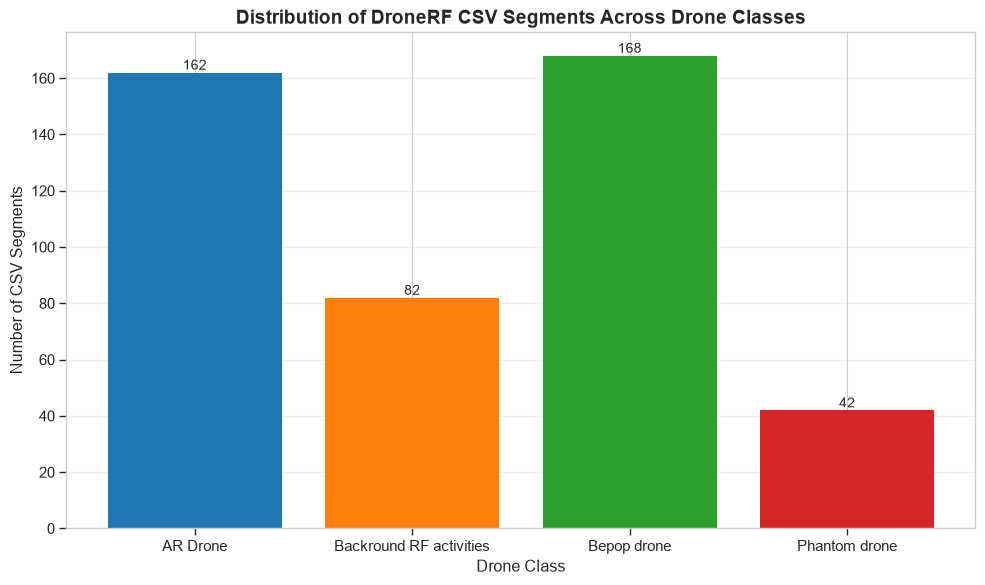

In [105]:
# ============================================================
# Drone Class Distribution
# ============================================================

if df_metadata.empty:
    print("Metadata DataFrame is empty.")

else:

    class_distribution = (
        df_metadata["drone_class"]
        .value_counts()
        .sort_index()
    )

    fig, ax = plt.subplots(figsize=(10, 6))
    
    colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

    bars = ax.bar(
        class_distribution.index,
        class_distribution.values,
        color=colors
    )

    ax.set_title(
        "Distribution of DroneRF CSV Segments Across Drone Classes",
        fontsize=14,
        fontweight="bold"
    )

    ax.set_xlabel("Drone Class")
    ax.set_ylabel("Number of CSV Segments")

    ax.grid(
        axis="y",
        alpha=0.3
    )

    for bar in bars:
        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{int(height)}",
            ha="center",
            va="bottom",
            fontsize=10
        )

    plt.tight_layout()

    figure_path = (
        NB_FIGURES_DIR / "class_distribution.png"
    )

    plt.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight"
    )

    print(f"Figure saved to: {figure_path}")

    plt.show()
    plt.close()

## Receiver Distribution

**Why are we performing this step?**  
To examine the distribution of RF recordings collected using different receiver configurations.

**What do we expect to observe?**  
A bar chart summarizing the number of RF recordings associated with each receiver type.

**Why is it important?**  
Receiver diversity provides insight into the range of RF conditions represented in the dataset. Understanding this distribution helps assess dataset completeness and informs the design of robust preprocessing and model evaluation strategies in subsequent notebooks.

Figure saved to: /Users/adithnarayan.g/Documents/Projects/Vardan/figures/notebook01/acquisition_identifier_distribution.png


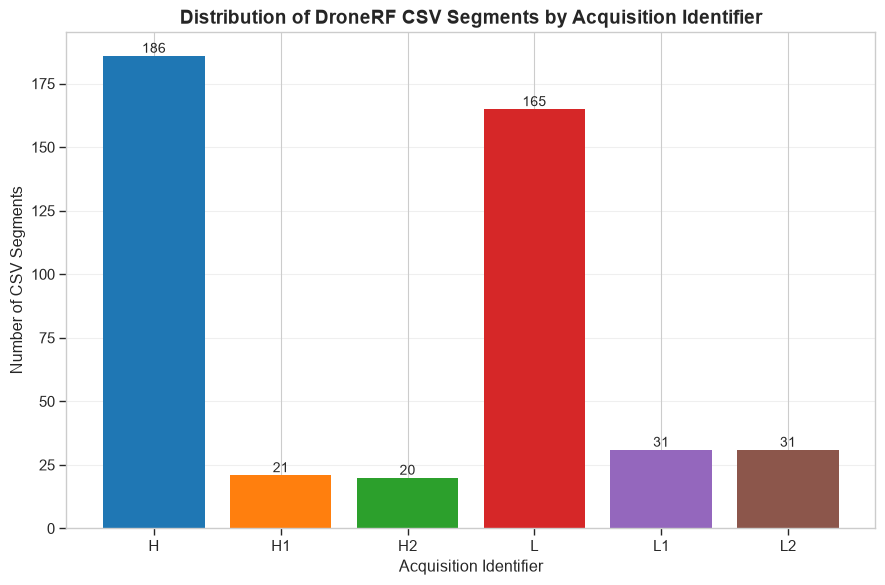

In [106]:
# ============================================================
# Acquisition Identifier Distribution
# ============================================================

if df_metadata.empty:
    print("Metadata DataFrame is empty.")

else:

    # Use the acquisition identifiers already extracted
    # and validated during metadata generation.
    acquisition_distribution = (
        df_metadata["receiver"]
        .value_counts()
        .sort_index()
    )

    # Keep a consistent order for readability
    preferred_order = ["H", "H1", "H2", "L", "L1", "L2"]

    acquisition_distribution = acquisition_distribution.reindex(
        preferred_order,
        fill_value=0
    )

    fig, ax = plt.subplots(figsize=(9, 6))

    # Different color for each acquisition identifier
    colors = [
        "tab:blue",
        "tab:orange",
        "tab:green",
        "tab:red",
        "tab:purple",
        "tab:brown"
    ]

    bars = ax.bar(
        acquisition_distribution.index,
        acquisition_distribution.values,
        color=colors
    )

    ax.set_title(
        "Distribution of DroneRF CSV Segments by Acquisition Identifier",
        fontsize=14,
        fontweight="bold"
    )

    ax.set_xlabel("Acquisition Identifier")
    ax.set_ylabel("Number of CSV Segments")

    ax.grid(
        axis="y",
        alpha=0.3
    )

    # Add count above each bar
    for bar in bars:
        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{int(height)}",
            ha="center",
            va="bottom",
            fontsize=10
        )

    plt.tight_layout()

    figure_path = (
        NB_FIGURES_DIR /
        "acquisition_identifier_distribution.png"
    )

    plt.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight"
    )

    print(f"Figure saved to: {figure_path}")

    plt.show()
    plt.close()

## Inspect Representative RF Recording

**Why are we performing this step?**  
To examine the metadata associated with a representative RF recording before loading any signal samples.

**What do we expect to observe?**  
The recording's drone class, experiment identifier, receiver type, segment identifier, file location, and storage characteristics.

**Why is it important?**  
Inspecting the metadata verifies that the representative recording has been selected correctly and provides context for the lightweight signal analysis performed in the following sections.

In [107]:
# ============================================================
# Inspect One Example RF CSV Segment
# ============================================================

print("=== Example RF CSV Segment ===\n")

# ------------------------------------------------------------
# Select a deterministic example
# ------------------------------------------------------------
# This file is selected only for structural inspection.
# It is NOT assumed to represent the complete AR Drone class.

example_candidates = df_metadata[
    (df_metadata["drone_class"] == "AR Drone")
    & (df_metadata["experiment_id"].astype(str) == "10100")
    & (df_metadata["receiver"] == "H")
    & (df_metadata["segment_id"].astype(int) == 0)
].copy()

# Verify that the expected sample exists
if example_candidates.empty:
    raise ValueError(
        "Expected AR Drone / experiment 10100 / "
        "acquisition H / segment 0 was not found."
    )

# There should normally be exactly one matching CSV
if len(example_candidates) > 1:
    print(
        f"Warning: {len(example_candidates)} matching files found. "
        "Using the first deterministic match."
    )

example_candidates = example_candidates.sort_values("relative_path")

example_meta = example_candidates.iloc[0]

# Construct full path
example_path = PROJECT_ROOT / example_meta["relative_path"]

# ------------------------------------------------------------
# Verify physical file
# ------------------------------------------------------------

if not example_path.exists():
    raise FileNotFoundError(
        f"Example RF CSV segment does not exist:\n{example_path}"
    )

# ------------------------------------------------------------
# Display metadata
# ------------------------------------------------------------

print(f"Drone Class       : {example_meta['drone_class']}")
print(f"Experiment ID     : {example_meta['experiment_id']}")
print(f"Acquisition ID    : {example_meta['receiver']}")
print(f"Segment ID        : {example_meta['segment_id']}")
print(f"File Name         : {example_path.name}")
print(f"Relative Path     : {example_meta['relative_path']}")

print(
    f"File Size         : "
    f"{example_meta['file_size_mb']:.2f} MB "
    f"({int(example_meta['file_size_bytes']):,} bytes)"
)

print("File Exists       : Yes")

# ------------------------------------------------------------
# Explain next step
# ------------------------------------------------------------

print("\nPurpose")
print("-" * 60)

print(
    f"The first {SAMPLE_SIZE:,} RF samples from this CSV segment "
    "will be loaded for structural inspection, basic validation, "
    "summary statistics, and visualization."
)

print(
    "\nThis CSV is used only as a deterministic example for "
    "dataset exploration. It is not treated as representative "
    "of the complete AR Drone class."
)

=== Example RF CSV Segment ===

Drone Class       : AR Drone
Experiment ID     : 10100
Acquisition ID    : H
Segment ID        : 0
File Name         : 10100H_0.csv
Relative Path     : data/raw/DroneRF/unzipped_data/AR Drone/RF Data_10100_H/10100H_0.csv
File Size         : 89.96 MB (94,330,241 bytes)
File Exists       : Yes

Purpose
------------------------------------------------------------
The first 10,000 RF samples from this CSV segment will be loaded for structural inspection, basic validation, summary statistics, and visualization.

This CSV is used only as a deterministic example for dataset exploration. It is not treated as representative of the complete AR Drone class.


## Load Representative RF Signal Subset

**Why are we performing this step?**  
To load a lightweight subset of the representative RF recording for exploratory analysis while avoiding the overhead of reading the complete recording.

**What do we expect to observe?**  
A one-dimensional NumPy array containing a configurable number of RF samples from the representative recording.

**Why is it important?**  
Loading only a small subset significantly reduces execution time and memory consumption while providing sufficient information for validation, descriptive statistics, and visualization in this notebook.

In [108]:
# ============================================================
# Load Example RF Signal Subset
# ============================================================

print("=== Loading Example RF Signal Subset ===")

# ------------------------------------------------------------
# Load only a small subset of the selected CSV segment
# ------------------------------------------------------------
# DroneRF CSV segments are very large (~90 MB each).
# Loading only the first SAMPLE_SIZE values keeps this
# exploratory inspection lightweight and memory-efficient.

rf_subset = (
    pd.read_csv(
        example_path,
        header=None,
        nrows=1,
        usecols=range(SAMPLE_SIZE),
        dtype=np.float32,
        engine="c",
    )
    .to_numpy(copy=False)
    .ravel()
)

# ------------------------------------------------------------
# Validate loaded subset
# ------------------------------------------------------------

if rf_subset.size != SAMPLE_SIZE:
    raise ValueError(
        f"Expected {SAMPLE_SIZE:,} RF samples, "
        f"but loaded {rf_subset.size:,}."
    )

# ------------------------------------------------------------
# Cache for subsequent inspection and visualization
# ------------------------------------------------------------

example_cache = {
    "metadata": example_meta,
    "path": example_path,
    "signal": rf_subset,
}

# ------------------------------------------------------------
# Loading Summary
# ------------------------------------------------------------

print(f"CSV segment       : {example_path.name}")
print(f"Drone class       : {example_meta['drone_class']}")
print(f"Experiment ID     : {example_meta['experiment_id']}")
print(f"Acquisition ID    : {example_meta['receiver']}")
print(f"Segment ID        : {example_meta['segment_id']}")
print(f"Samples loaded    : {rf_subset.size:,}")
print(f"Array shape       : {rf_subset.shape}")
print(f"Data type         : {rf_subset.dtype}")
print(
    f"Memory usage      : "
    f"{rf_subset.nbytes / (1024 ** 2):.3f} MB"
)

print("\n✓ RF signal subset loaded successfully.")

=== Loading Example RF Signal Subset ===
CSV segment       : 10100H_0.csv
Drone class       : AR Drone
Experiment ID     : 10100
Acquisition ID    : H
Segment ID        : 0
Samples loaded    : 10,000
Array shape       : (10000,)
Data type         : float32
Memory usage      : 0.038 MB

✓ RF signal subset loaded successfully.


## Dataset Validation

**Why are we performing this step?**  
To verify that the loaded representative RF signal subset is numerically valid before statistical analysis and visualization.

**What do we expect to observe?**  
A valid one-dimensional numeric signal with no missing values, no infinite values, and the expected number of samples.

**Why is it important?**  
Verifying numerical integrity ensures that subsequent preprocessing, feature extraction, and visualization steps operate on valid signal data, reducing the risk of unexpected errors or misleading analytical results.

In [109]:
# ============================================================
# Validate Example RF Signal Subset
# ============================================================

print("=== Example RF Signal Validation ===\n")

# Retrieve cached signal and metadata
signal = example_cache["signal"]
meta = example_cache["metadata"]

# ------------------------------------------------------------
# Example Segment Information
# ------------------------------------------------------------

print("Example RF CSV Segment")
print("-" * 60)

print(f"Drone Class       : {meta['drone_class']}")
print(f"Experiment ID     : {meta['experiment_id']}")
print(f"Acquisition ID    : {meta['receiver']}")
print(f"Segment ID        : {meta['segment_id']}")
print(f"Samples Loaded    : {signal.size:,}")
print(f"Array Shape       : {signal.shape}")
print(f"Data Type         : {signal.dtype}")
print()

# ------------------------------------------------------------
# Numerical Validation
# ------------------------------------------------------------

validation_results = {
    "Expected Sample Size":
        signal.size == SAMPLE_SIZE,

    "Numeric Data":
        np.issubdtype(signal.dtype, np.number),

    "No Missing Values (NaN)":
        not np.isnan(signal).any(),

    "No Infinite Values":
        not np.isinf(signal).any(),

    "Non-Empty Signal":
        signal.size > 0,

    "One-Dimensional Signal":
        signal.ndim == 1
}

validation_df = pd.DataFrame(
    validation_results.items(),
    columns=["Validation Check", "Result"]
)

validation_df["Result"] = validation_df["Result"].map(
    lambda result: "PASS" if result else "FAIL"
)

display(validation_df)

# ------------------------------------------------------------
# Basic Signal Statistics
# ------------------------------------------------------------

signal_statistics = {
    "Minimum": np.min(signal),
    "Maximum": np.max(signal),
    "Mean": np.mean(signal),
    "Standard Deviation": np.std(signal),
    "Memory Usage (MB)": signal.nbytes / (1024 ** 2)
}

statistics_df = pd.DataFrame(
    signal_statistics.items(),
    columns=["Statistic", "Value"]
)

display(statistics_df)

# ------------------------------------------------------------
# Overall Validation Status
# ------------------------------------------------------------

passed_checks = all(validation_results.values())

if not passed_checks:
    raise ValueError(
        "Example RF signal subset failed one or more "
        "validation checks."
    )

print("✓ Example RF signal subset passed all validation checks.")

=== Example RF Signal Validation ===

Example RF CSV Segment
------------------------------------------------------------
Drone Class       : AR Drone
Experiment ID     : 10100
Acquisition ID    : H
Segment ID        : 0
Samples Loaded    : 10,000
Array Shape       : (10000,)
Data Type         : float32



,Validation Check,Result
0,Expected Sample Size,PASS
1,Numeric Data,PASS
2,No Missing Values (NaN),PASS
3,No Infinite Values,PASS
4,Non-Empty Signal,PASS
5,One-Dimensional Signal,PASS


,Statistic,Value
0,Minimum,-28.000000
1,Maximum,43.000000
2,Mean,0.028800
3,Standard Deviation,2.573785
4,Memory Usage (MB),0.038147


✓ Example RF signal subset passed all validation checks.


## Signal Visualization

**Why we are performing this step:** To observe the time-domain behavior and probability distributions of the RF amplitudes.
**What we expect to observe:** Global signal shape, fine structural details in a subset of samples, and overall distribution properties.
**Why it is important:** Visual intuition dictates preprocessing tactics, indicating whether the signal is highly non-stationary or requires normalization before Fourier Transforms.


=== Example RF Signal Visualization ===
Figure saved to: /Users/adithnarayan.g/Documents/Projects/Vardan/figures/notebook01/example_rf_signal.png


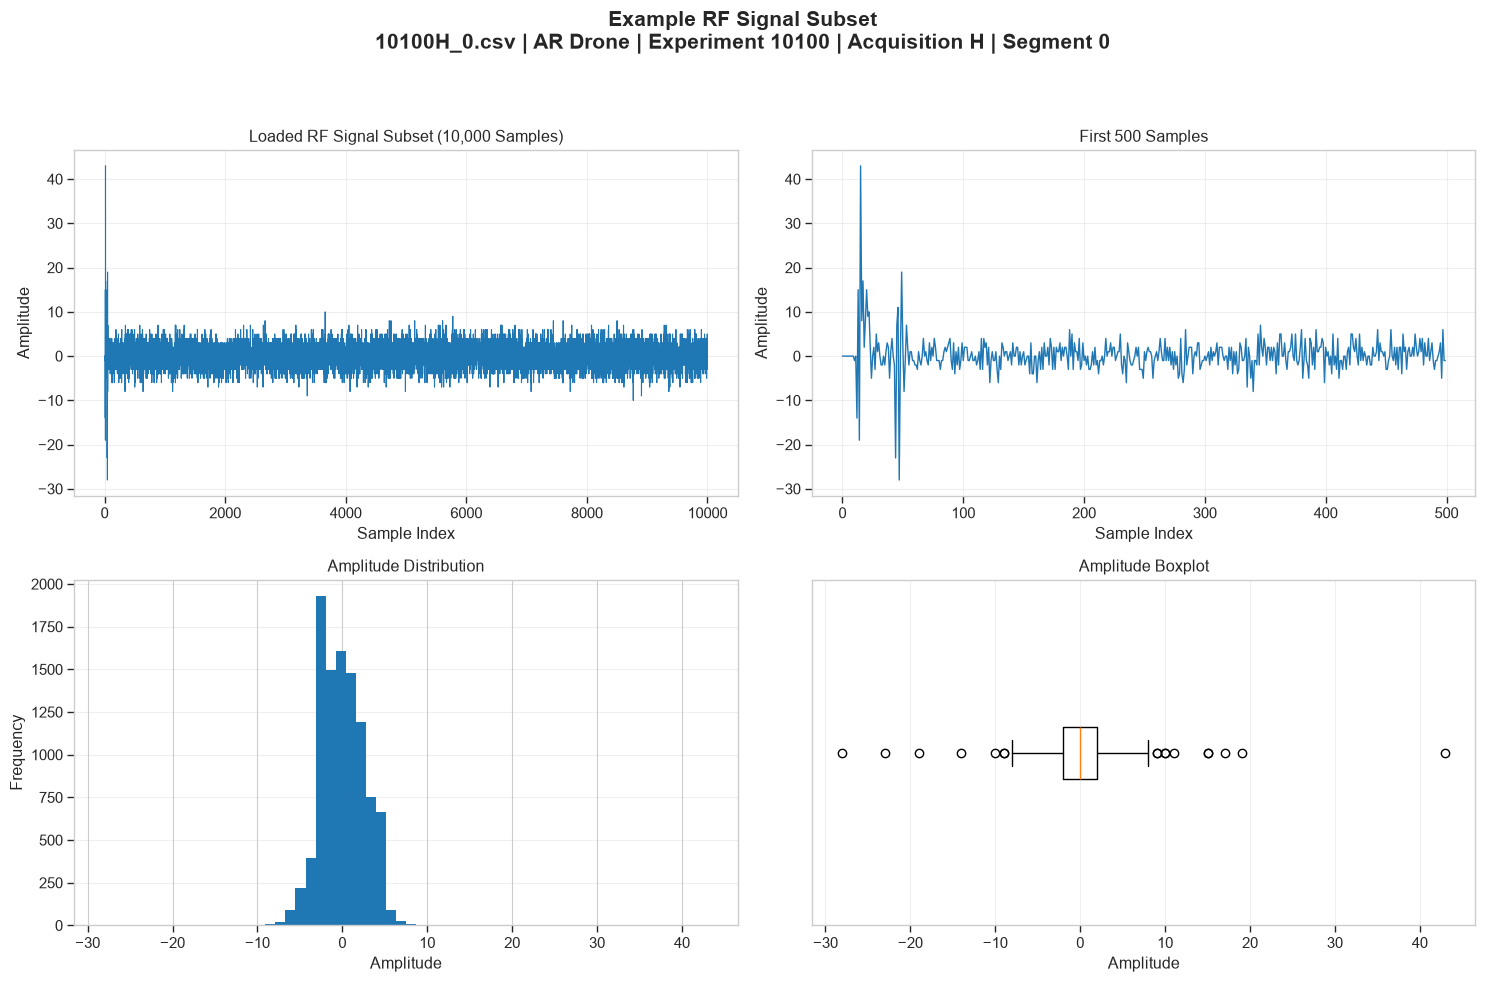

In [110]:
# ============================================================
# Example RF Signal Visualization
# ============================================================

print("=== Example RF Signal Visualization ===")

signal = example_cache["signal"]
meta = example_cache["metadata"]
signal_path = example_cache["path"]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(15, 10)
)

fig.suptitle(
    (
        f"Example RF Signal Subset\n"
        f"{signal_path.name} | "
        f"{meta['drone_class']} | "
        f"Experiment {meta['experiment_id']} | "
        f"Acquisition {meta['receiver']} | "
        f"Segment {meta['segment_id']}"
    ),
    fontsize=15,
    fontweight="bold"
)

# ------------------------------------------------------------
# 1. Complete Loaded Subset
# ------------------------------------------------------------

axes[0, 0].plot(
    signal,
    linewidth=0.8
)

axes[0, 0].set_title(
    f"Loaded RF Signal Subset ({signal.size:,} Samples)"
)

axes[0, 0].set_xlabel("Sample Index")
axes[0, 0].set_ylabel("Amplitude")
axes[0, 0].grid(alpha=0.3)

# ------------------------------------------------------------
# 2. First 500 Samples
# ------------------------------------------------------------

zoom_samples = min(500, signal.size)

axes[0, 1].plot(
    signal[:zoom_samples],
    linewidth=1
)

axes[0, 1].set_title(
    f"First {zoom_samples} Samples"
)

axes[0, 1].set_xlabel("Sample Index")
axes[0, 1].set_ylabel("Amplitude")
axes[0, 1].grid(alpha=0.3)

# ------------------------------------------------------------
# 3. Amplitude Distribution
# ------------------------------------------------------------

axes[1, 0].hist(
    signal,
    bins=60
)

axes[1, 0].set_title(
    "Amplitude Distribution"
)

axes[1, 0].set_xlabel("Amplitude")
axes[1, 0].set_ylabel("Frequency")
axes[1, 0].grid(
    axis="y",
    alpha=0.3
)

# ------------------------------------------------------------
# 4. Amplitude Boxplot
# ------------------------------------------------------------

axes[1, 1].boxplot(
    signal,
    vert=False
)

axes[1, 1].set_title(
    "Amplitude Boxplot"
)

axes[1, 1].set_xlabel("Amplitude")
axes[1, 1].set_yticks([])
axes[1, 1].grid(
    axis="x",
    alpha=0.3
)

# ------------------------------------------------------------
# Save Figure
# ------------------------------------------------------------

plt.tight_layout(
    rect=[0, 0, 1, 0.94]
)

figure_path = (
    NB_FIGURES_DIR /
    "example_rf_signal.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

print(f"Figure saved to: {figure_path}")

plt.show()
plt.close()

## Research Observations

Based exclusively on the dataset exploration performed in this notebook, the following observations can be made:

- **Dataset scale:** The extracted DroneRF dataset contains **454 CSV segments** occupying approximately **40.38 GB**.

- **Class structure:** Four top-level classes were identified:
  - AR Drone — 162 CSV segments
  - Bebop drone — 168 CSV segments
  - Phantom drone — 42 CSV segments
  - Background RF activities — 82 CSV segments

- **Experiment structure:** A total of **10 unique experiment identifiers** were extracted from the dataset hierarchy. AR Drone and Bebop drone contain four experiment identifiers each, while Background RF activities and Phantom drone contain one each.

- **Acquisition identifiers:** Six acquisition identifiers were observed in the extracted directory structure: `H`, `H1`, `H2`, `L`, `L1`, and `L2`. Their precise physical interpretation should be established from the DroneRF acquisition methodology rather than inferred solely from their names.

- **Segment structure:** Individual experiment/acquisition directories contain multiple numbered CSV segments. These segment identifiers were successfully extracted into the metadata index.

- **Class imbalance:** The number of available CSV segments differs substantially between classes. In particular, Phantom drone contains considerably fewer segments than AR Drone or Bebop drone. This imbalance must be considered when designing later training and evaluation protocols.

- **Example signal structure:** Inspection of the first 10,000 values of `10100H_0.csv` confirmed that the loaded RF subset is a one-dimensional numerical array with no NaN or infinite values.

- **Example amplitude behaviour:** Within this specific 10,000-sample subset, amplitudes are concentrated near the central region while several comparatively large excursions are visible. These observations apply only to the inspected subset and are not assumed to characterize the complete AR Drone class.

No conclusions regarding class separability, drone-specific RF signatures, optimal preprocessing, or model performance are made in this notebook.

## Dataset Verification Status

The extracted DroneRF data was successfully discovered and structurally validated.

| Property | Observed in Extracted Dataset | Status |
| :--- | :--- | :--- |
| Top-level classes | AR Drone, Bebop drone, Phantom drone, Background RF activities | ✓ Confirmed |
| Total CSV segments | 454 | ✓ Confirmed |
| Experiment identifiers | 10 unique identifiers | ✓ Confirmed |
| Acquisition identifiers | H, H1, H2, L, L1, L2 | ✓ Confirmed |
| Numbered CSV segments | Segment identifiers extracted from filenames | ✓ Confirmed |
| CSV-based numerical storage | Successfully loaded and numerically validated | ✓ Confirmed |
| Missing values in inspected subset | None detected | ✓ Confirmed |
| Infinite values in inspected subset | None detected | ✓ Confirmed |

The metadata index generated in this notebook therefore provides a reproducible mapping between drone class, experiment identifier, acquisition identifier, segment identifier, and physical CSV location.

The physical meaning of the acquisition identifiers and the signal acquisition configuration should be interpreted using the original DroneRF dataset documentation and publication rather than inferred solely from directory or filename conventions.

## Research Questions for Notebook 02

Notebook 01 established the dataset structure. Notebook 02 will move from structural exploration to RF signal analysis and preprocessing.

The following questions will guide the next stage:

1. **Acquisition interpretation**  
   What do the `H`, `H1`, `H2`, `L`, `L1`, and `L2` identifiers represent in the DroneRF acquisition methodology?

2. **Cross-recording consistency**  
   How do signal amplitude statistics vary across drone classes, experiments, acquisition identifiers, and CSV segments?

3. **Signal scaling**  
   Are the recordings already represented on comparable numerical scales, or is normalization/standardization required?

4. **Time-domain behaviour**  
   Are transient structures, bursts, or other recurring patterns visible across multiple recordings?

5. **Frequency-domain behaviour**  
   Does Fourier-domain analysis reveal useful spectral structure that differs between background activity and drone recordings?

6. **Time-frequency behaviour**  
   If the RF signals are non-stationary, does STFT-based analysis provide information that is obscured by a global FFT?

7. **Preprocessing strategy**  
   Based on the above evidence, what preprocessing pipeline should be adopted before reproducing baseline models?

No preprocessing method will be selected solely by assumption; the choice will be supported by empirical analysis and the DroneRF acquisition methodology.

## Research Summary

### Key Findings

Notebook 01 established a reproducible structural understanding of the extracted DroneRF dataset.

The dataset contains **454 CSV segments across four classes**, with approximately **40.38 GB** of extracted RF data. Experiment identifiers, acquisition identifiers, segment identifiers, class labels, file sizes, and file locations were successfully indexed.

A deterministic example (`AR Drone / 10100 / H / segment 0`) was inspected using a 10,000-sample subset. The subset was confirmed to contain valid one-dimensional numerical data without NaN or infinite values and was visualized using time-domain, histogram, and boxplot views.

The example inspection was performed only to validate the data representation and establish the exploratory workflow. It is not treated as representative of the complete AR Drone class.

### Research Deliverables

Notebook 01 produced:

- a reproducible metadata index: `data/metadata/dronerf_metadata.csv`;
- dataset-level class, experiment, acquisition-identifier, and storage statistics;
- dataset-distribution figures;
- validation of the RF CSV loading procedure;
- an initial visualization of one deterministic RF signal subset.

### Methodological Boundary

Notebook 01 performs **dataset discovery and structural validation only**.

It does not perform:

- signal filtering;
- normalization or standardization;
- FFT or spectral feature extraction;
- STFT or spectrogram generation;
- feature engineering;
- train/validation/test splitting;
- model training;
- classification;
- baseline benchmarking.

These tasks are intentionally deferred until the RF signal characteristics and acquisition methodology have been investigated systematically.

### Next Stage

**Notebook 02 — RF Signal Processing**

Notebook 02 will use the metadata index generated here rather than rediscovering the raw directory structure. It will investigate signals across classes, experiments, acquisition identifiers, and segments before defining the preprocessing pipeline that will subsequently be used for baseline reproduction and Vardan RF model development.